# Glacial lakes from space: a walkthrough

This notebook is the friendly tour of the project. Run it top to bottom (in VS Code: **Run All**).

1. Look at a few chips: what the 11 bands actually show
2. Check how rare lake pixels are (this shapes the choice of loss function)
3. Compare the methods once the scripts in `src/` have been run
4. Look at where the U-Net gets it right and wrong

In [1]:
import sys, json, glob
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

sys.path.append("../src")          # so we can reuse the project's own code
from dataset import BAND_NAMES, find_pairs, region_of, HIMALAYA_REGIONS

DATA = Path("../data/glb_subset")
test_pairs = find_pairs(DATA, "test")
himalaya = [p for p in test_pairs if region_of(p[0]) in HIMALAYA_REGIONS]
print(f"{len(test_pairs)} test chips, {len(himalaya)} of them in the Himalaya")

740 test chips, 351 of them in the Himalaya


## 1. What does one chip look like?

We pick a Himalayan chip that actually contains a lake and show it five ways:
true colour, NDWI (water shows up bright), elevation, radar (VV), and the answer key (mask).

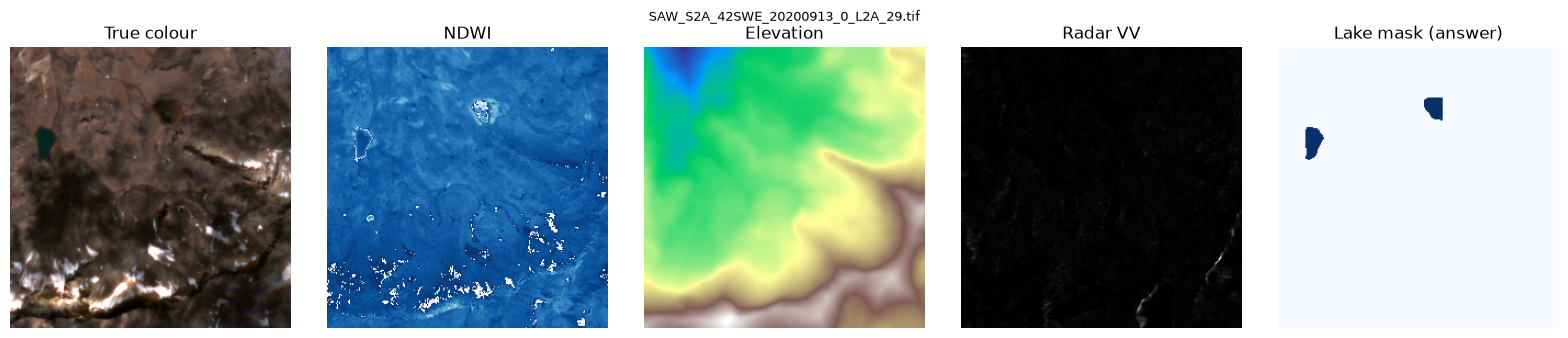

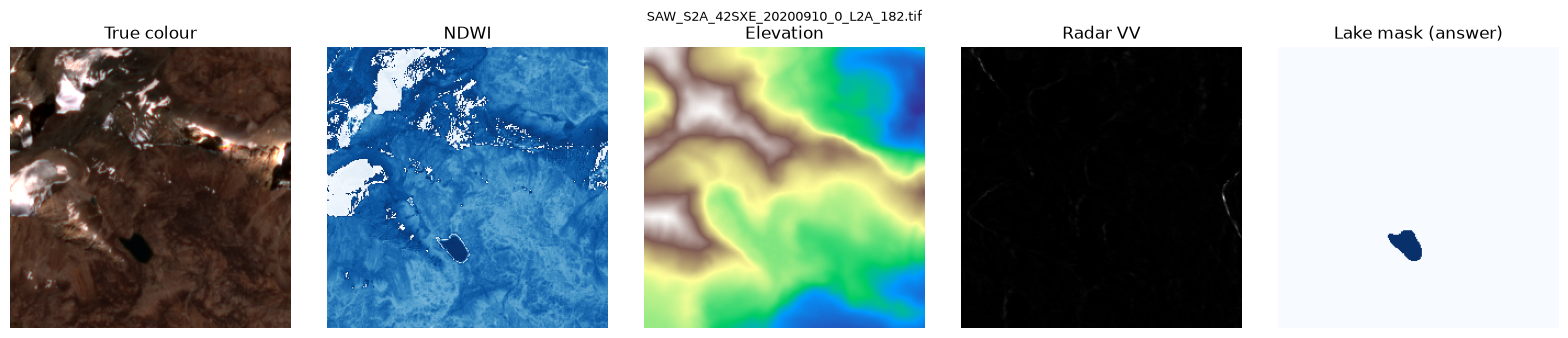

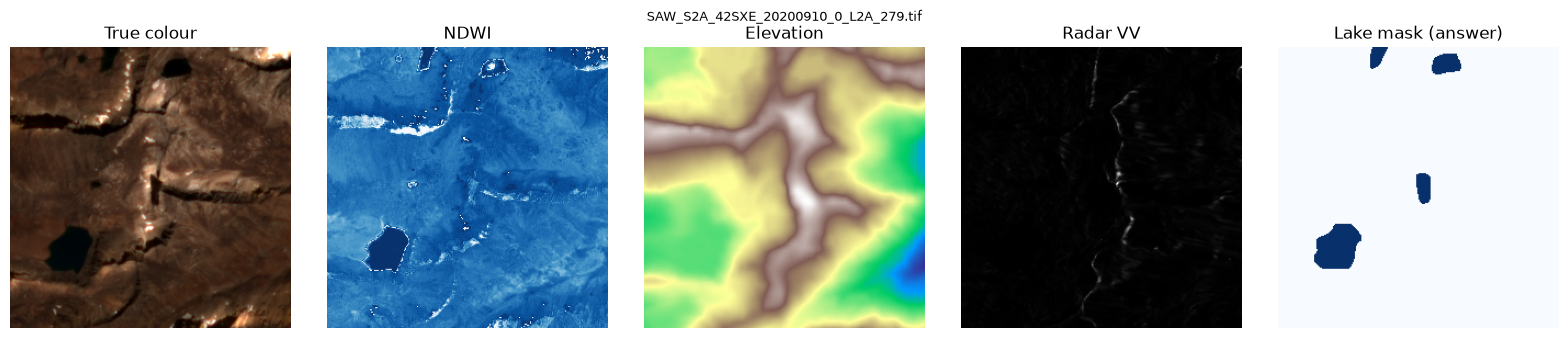

In [2]:
def read(pair):
    with rasterio.open(pair[0]) as s: img = np.nan_to_num(s.read())
    with rasterio.open(pair[1]) as s: mask = s.read(1)
    return img, mask

def show_chip(pair):
    img, mask = read(pair)
    rgb = np.clip(img[[2, 1, 0]].transpose(1, 2, 0) * 2.5, 0, 1)   # Red, Green, Blue, brightened
    panels = [("True colour", rgb, None), ("NDWI", img[6], "Blues"),
              ("Elevation", img[8], "terrain"), ("Radar VV", img[9], "gray"),
              ("Lake mask (answer)", mask, "Blues")]
    fig, axes = plt.subplots(1, 5, figsize=(16, 3.4))
    for ax, (title, arr, cmap) in zip(axes, panels):
        ax.imshow(arr, cmap=cmap); ax.set_title(title); ax.axis("off")
    fig.suptitle(pair[0].name, fontsize=9); plt.tight_layout(); plt.show()

with_lake = [p for p in himalaya if read(p)[1].sum() > 500]
for pair in with_lake[:3]:
    show_chip(pair)

## 2. How rare are lake pixels?

If only a few percent of pixels are lake, a lazy model could score 97% accuracy by predicting "no lake" everywhere.
That's why training uses Dice loss (overlap), not plain accuracy.

Average share of lake pixels per chip: 3.7%
Chips with no lake at all: 0.7%


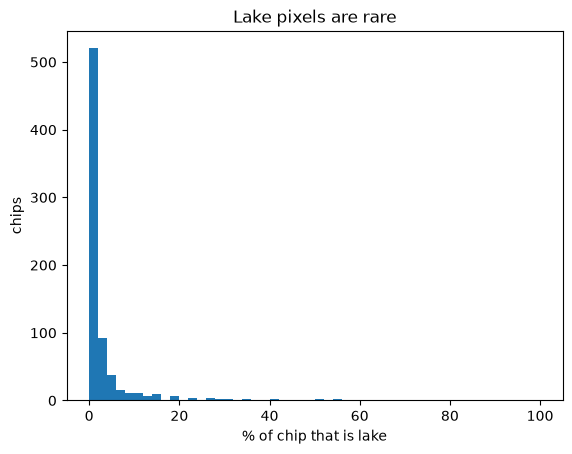

In [3]:
fractions = [read(p)[1].mean() for p in test_pairs]
print(f"Average share of lake pixels per chip: {np.mean(fractions):.1%}")
print(f"Chips with no lake at all: {np.mean(np.array(fractions) == 0):.1%}")
plt.hist(np.array(fractions) * 100, bins=50); plt.xlabel("% of chip that is lake"); plt.ylabel("chips")
plt.title("Lake pixels are rare"); plt.show()

## 3. How do the methods compare?

Each script in `src/` writes `results/<method>_summary.json`. This cell collects whatever has been run so far.

In [4]:
rows = []
for f in sorted(glob.glob("../results/*_summary.json")):
    method = Path(f).name.replace("_summary.json", "")
    for test_set, scores in json.load(open(f)).items():
        rows.append({"method": method, "set": test_set, **scores})
results = pd.DataFrame(rows)
results.pivot(index="method", columns="set", values="lake_IoU").round(3) if len(results) else "Run the scripts in src/ first"


set,challenge,himalaya,test
method,,,
ndwi_otsu,0.062,0.112,0.130
ndwi_plus_slope,0.180,0.217,0.241
ndwi_recomputed,0.095,0.222,0.246
ndwi_stored_band,0.016,0.038,0.043
unet_all,0.360,0.390,0.443
unet_optical,0.114,0.265,0.370


### Which regions are hardest?

Per-chip results let us break the score down by glacier region. Keep an eye on SA and SAW (the Himalaya).

In [5]:
per_chip = pd.concat([pd.read_csv(f).assign(method=Path(f).name.replace("_per_chip.csv", ""))
                      for f in glob.glob("../results/*_per_chip.csv")])
by_region = (per_chip[per_chip.set == "test"]
             .groupby(["region", "method"]).iou.mean().unstack().round(3))
by_region

method,ndwi_otsu,ndwi_plus_slope,ndwi_recomputed,ndwi_stored_band,unet_all,unet_optical
region,,,,,,
AC,0.127,0.176,0.187,0.100,0.399,0.193
ACS,0.356,0.372,0.389,0.071,0.690,0.622
AK,0.122,0.285,0.290,0.026,0.481,0.494
CA,0.154,0.290,0.289,0.023,0.513,0.535
CE,0.020,0.286,0.294,0.043,0.507,0.466
GL,0.197,0.254,0.248,0.067,0.476,0.440
IS,0.002,0.541,0.559,0.048,0.741,0.431
LL,0.112,0.318,0.223,0.056,0.546,0.463
ME,0.030,0.481,0.606,0.006,0.917,0.902


## 4. Where does the U-Net go wrong?

Load the trained model and show its worst Himalayan chips next to the truth. Looking at failures is how you learn
what the model has *not* understood (shadows? frozen lakes? rivers mistaken for lakes?).

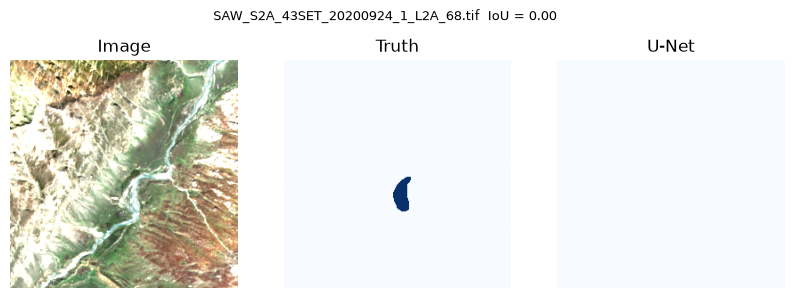

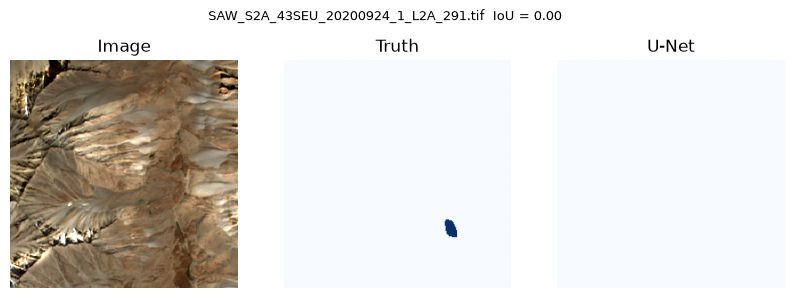

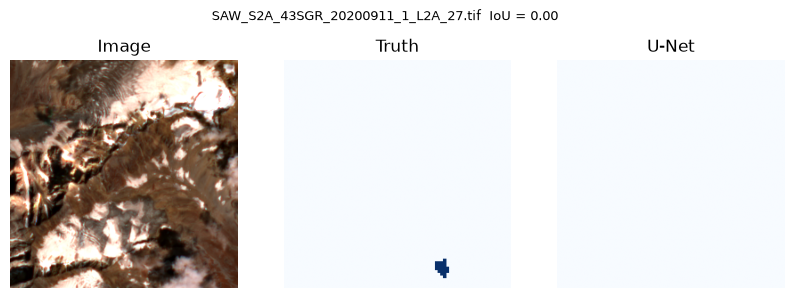

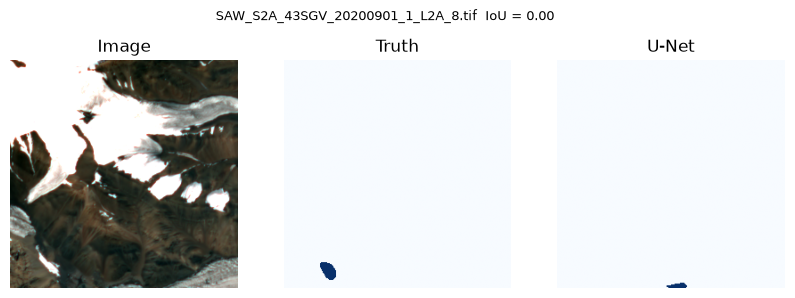

In [6]:
import torch
from train_unet import build_model, pick_device

device = pick_device()
ckpt = torch.load("../checkpoints/unet_all.pt", map_location=device)
model = build_model(len(ckpt["bands"])).to(device)
model.load_state_dict(ckpt["model"]); model.eval()

def predict(img):
    with torch.no_grad():
        x = torch.from_numpy(img[ckpt["bands"]].astype(np.float32))[None].to(device)
        return (model(x)[0, 0] > 0).cpu().numpy()

unet = per_chip[(per_chip.method == "unet_all") & (per_chip.set == "himalaya")]
worst = unet[unet.lake_pixels_true > 200].nsmallest(4, "iou")
for name in worst.file:
    pair = next(p for p in himalaya if p[0].name == name)
    img, mask = read(pair)
    rgb = np.clip(img[[2, 1, 0]].transpose(1, 2, 0) * 2.5, 0, 1)
    fig, ax = plt.subplots(1, 3, figsize=(10, 3.4))
    for a, (t, arr) in zip(ax, [("Image", rgb), ("Truth", mask), ("U-Net", predict(img))]):
        a.imshow(arr, cmap=None if t == "Image" else "Blues"); a.set_title(t); a.axis("off")
    fig.suptitle(f"{name}  IoU = {worst.set_index('file').loc[name, 'iou']:.2f}", fontsize=9); plt.show()